In [89]:
# CONFIGURATION
TEAM_ID     = 2829
total_min    = 607
PLAYER_NAME = "Jude Bellingham"
UCL_ID      = "7"
SEASON_ID   = "76953"
logo = "rm_logo.PNG"
Team_name = "Real Madrid | UEFA Champions League 2025/26"

In [84]:
from sofascoreapi import League, MatchStats, Team, _fetch, BASE_URL

#Fetch group stage matches
matches  = []
round_n  = 1
while True:
    try:
        data   = _fetch(f"{BASE_URL}/unique-tournament/{UCL_ID}/season/{SEASON_ID}/events/round/{round_n}")
        events = data.get("events", [])
        if not events:
            break
        for ev in events:
            home_id = ev["homeTeam"]["id"]
            away_id = ev["awayTeam"]["id"]
            status  = ev["status"]["type"]
            if TEAM_ID in (home_id, away_id) and status == "finished":
                matches.append({
                    "match_id": str(ev["id"]),
                    "round":    round_n,
                    "home":     ev["homeTeam"]["name"],
                    "away":     ev["awayTeam"]["name"],
                })
        round_n += 1
    except Exception:
        break

#Fetch knockout matches
page = 0
while True:
    try:
        data   = _fetch(f"{BASE_URL}/team/{TEAM_ID}/events/last/{page}")
        events = data.get("events", [])
        if not events:
            break
        for ev in events:
            tid    = ev.get("tournament", {}).get("uniqueTournament", {}).get("id")
            sid    = ev.get("season", {}).get("id")
            status = ev.get("status", {}).get("type", "")
            if str(tid) == UCL_ID and str(sid) == SEASON_ID and status == "finished":
                mid = str(ev["id"])
                if not any(m["match_id"] == mid for m in matches):
                    matches.append({
                        "match_id": mid,
                        "round":    "KO",
                        "home":     ev["homeTeam"]["name"],
                        "away":     ev["awayTeam"]["name"],
                    })
        page += 1
    except Exception:
        break

print(f"Total matches found: {len(matches)}")

#Get player ID
squad       = Team(str(TEAM_ID)).get_squad()
player_id   = None
for entry in squad["players"]:
    if entry["player"]["name"].lower() == PLAYER_NAME.lower():
        player_id = entry["player"]["id"]
        break

if not player_id:
    raise ValueError(f"Player '{PLAYER_NAME}' not found in squad")
print(f"Player ID: {player_id}")

#Extract shots
shots = []
for match in matches:
    try:
        shot_data = MatchStats(match["match_id"]).get_shotmap()
        for s in shot_data.get("shotmap", []):
            if s.get("player", {}).get("id") != player_id:
                continue
            coord      = s.get("playerCoordinates", {})
            goal_mouth = s.get("goalMouthCoordinates", {})
            shots.append({
                "match_id":          match["match_id"],
                "round":             match["round"],
                "home_team":         match["home"],
                "away_team":         match["away"],
                "x":                 coord.get("x"),
                "y":                 coord.get("y"),
                "xg":                s.get("xg"),
                "result":            s.get("shotType"),
                "body_part":         s.get("bodyPart"),
                "situation":         s.get("situation"),
                "target_zone":       s.get("goalMouthLocation"),
                "goal_mouth_y":      goal_mouth.get("y", 50),
                "minute":            s.get("time"),
            })
    except Exception as e:
        print(f"Skipping match {match['match_id']}: {e}")

print(f"Total shots: {len(shots)}")

#Build dataframe
import pandas as pd
df = pd.DataFrame(shots)
print(df['result'].value_counts())

Total matches found: 14
Player ID: 991011
Total shots: 17
result
block    7
miss     6
goal     2
save     2
Name: count, dtype: int64


In [85]:
df

,match_id,round,home_team,away_team,x,y,xg,result,body_part,situation,target_zone,goal_mouth_y,minute
0,14566983,2,Kairat Almaty,Real Madrid,21.0,42.5,0.103728,save,right-foot,fast-break,low-centre,51.0,90
1,14566596,3,Real Madrid,Juventus,4.4,48.4,0.809195,goal,left-foot,regular,low-right,47.8,57
2,14566596,3,Real Madrid,Juventus,18.1,45.5,0.040101,block,right-foot,assisted,low-centre,50.3,55
3,14566596,3,Real Madrid,Juventus,8.5,51.3,0.142927,miss,head,corner,left,61.7,53
4,14566636,4,Liverpool FC,Real Madrid,3.4,34.4,0.148284,save,left-foot,assisted,low-left,53.2,45
5,14566865,5,Olympiacos FC,Real Madrid,15.2,51.6,0.062196,block,right-foot,assisted,low-centre,50.9,68
6,14566595,6,Real Madrid,Manchester City,10.7,51.9,0.112670,block,left-foot,regular,low-centre,50.9,86
7,14566595,6,Real Madrid,Manchester City,17.3,65.4,0.045472,block,left-foot,assisted,low-centre,50.1,75
8,14566595,6,Real Madrid,Manchester City,7.7,66.0,0.280508,miss,right-foot,fast-break,high,48.2,50
9,14566598,7,Real Madrid,AS Monaco,8.4,33.4,0.116124,miss,left-foot,fast-break,close-left,57.3,83


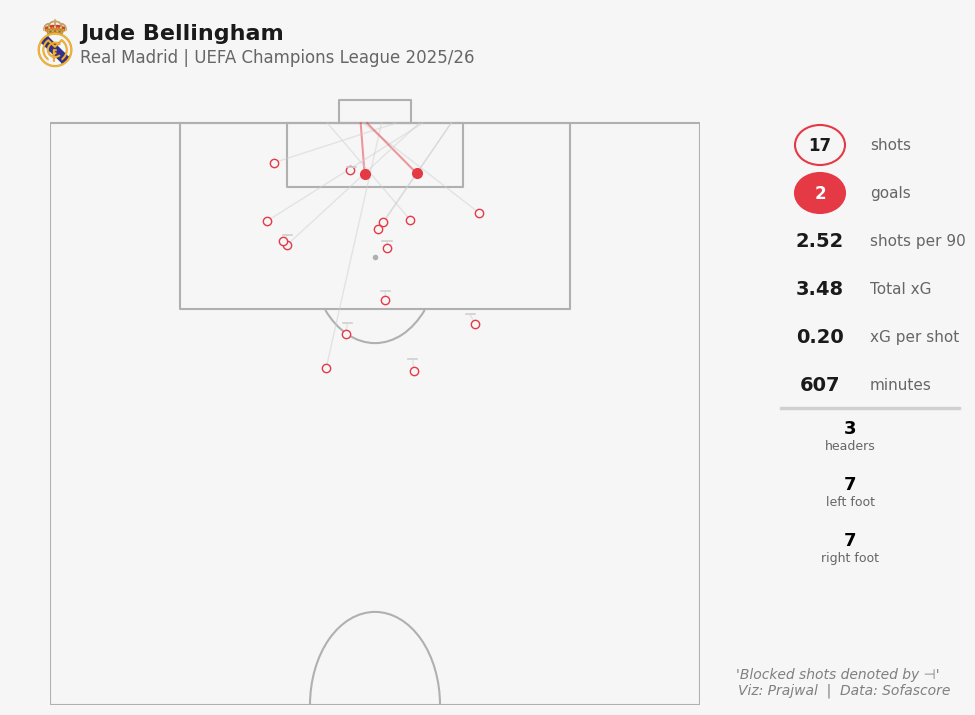

In [96]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
import numpy as np

# --- Calculations ---
total_shots  = len(df)
goals        = len(df[df['result'] == 'goal'])
shots_per_90 = (total_shots / total_min) * 90
total_xg     = df['xg'].sum()
xg_per_shot  = total_xg / total_shots
headers      = len(df[df['body_part'] == 'head'])
left_foot    = len(df[df['body_part'] == 'left-foot'])
right_foot   = len(df[df['body_part'] == 'right-foot'])

# --- Figure ---
fig = plt.figure(figsize=(10, 8), facecolor='#F6F6F6')
ax  = fig.add_axes([0.05, 0.05, 0.65, 0.8])
ax.set_facecolor('#F6F6F6')
ax.set_xlim(0, 100)
ax.set_ylim(50, -5)
ax.axis('off')


# --- Pitch Lines ---
pitch_color = '#B0B0B0'
ax.plot([0, 100, 100, 0, 0],               [0, 0, 50, 50, 0],   color=pitch_color, lw=1.5)
ax.plot([20, 80, 80, 20, 20],              [0, 0, 16, 16, 0],   color=pitch_color, lw=1.5)
ax.plot([36.5, 63.5, 63.5, 36.5, 36.5],   [0, 0, 5.5, 5.5, 0], color=pitch_color, lw=1.5)
ax.plot([44.5, 55.5, 55.5, 44.5, 44.5],   [0, 0, -2, -2, 0],   color=pitch_color, lw=1.5)
ax.plot(50, 11.5, 'o', color=pitch_color, markersize=3)

# D-arc: only draw segment outside penalty box
# Arc center (50,11.5), height=16 → crosses box line y=16 at sin(θ)=4.5/8=0.5625 → θ≈34° and 146°
arc = patches.Arc((50, 10.9), 20, 16, theta1=34, theta2=146, color=pitch_color, lw=1.5)
ax.add_patch(arc)

# Centre circle half
arc_center = patches.Arc((50, 50), 20, 16, theta1=180, theta2=360, color=pitch_color, lw=1.5)
ax.add_patch(arc_center)

# --- Plot Shots ---
for i, row in df.iterrows():
    x, y    = row['x'], row['y']
    is_goal = row['result'] == 'goal'
    is_blocked = row['result'] == 'block'

    if is_goal:
        ax.plot([y, row['goal_mouth_y']], [x, 0], color='#E63946', alpha=0.5, lw=1.5, zorder=2)
        ax.plot(y, x, 'o', color='#E63946', markeredgecolor='#E63946', markersize=7, zorder=5)

    elif is_blocked:
        t     = 0.05
        end_y = y + t * (row['goal_mouth_y'] - y)
        end_x = x * (1 - t)
        ax.plot([y, end_y], [x, end_x], color='#D0D0D0', alpha=0.5, lw=1, zorder=2)
        ax.plot(y, x, 'o', color='#F6F6F6', markeredgecolor='#E63946', markersize=6, lw=1.5, zorder=4)
        ax.plot([end_y - 0.7, end_y + 0.7], [end_x, end_x], color='#D0D0D0', lw=1.2, zorder=7)

    else:
         ax.plot([y, row['goal_mouth_y']], [x, 0], color='#D0D0D0', alpha=0.5, lw=1, zorder=2)
         ax.plot(y, x, 'o', color='#F6F6F6', markeredgecolor='#E63946', markersize=6, lw=1.5, zorder=4)
        
# --- Title ---
fig.text(0.08, 0.89, "Jude Bellingham",
         fontsize=16, fontweight='bold', va='center', color='#1A1A1A')
fig.text(0.08, 0.86,  Team_name,
         fontsize=12, color='#666666', va='center')

# --- Logo ---
from PIL import Image
import numpy as np

img  = Image.open(logo).convert('RGBA')
data = np.array(img)
white = (data[:,:,0] > 200) & (data[:,:,1] > 200) & (data[:,:,2] > 200)
data[white, 3] = 0

logo_ax = fig.add_axes([0.01, 0.835, 0.09, 0.085])
logo_ax.imshow(Image.fromarray(data))
logo_ax.axis('off')

# --- Stats Panel ---
cx       = 0.82
cx_label = 0.87
start_y  = 0.75
gap      = 0.06

def add_stat(val, label, y_pos, highlight=False, is_circle=False):
    if is_circle:
        circle = patches.Circle((cx, y_pos), 0.025, transform=fig.transFigure,
                                 facecolor='#E63946' if highlight else 'none',
                                 edgecolor='#E63946', lw=1.5)
        fig.patches.append(circle)
        fig.text(cx, y_pos, val, fontsize=12, fontweight='bold',
                 color='white' if highlight else '#1A1A1A',
                 ha='center', va='center')
    else:
        fig.text(cx, y_pos, val, fontsize=14, fontweight='bold',
                 color='#1A1A1A', ha='center', va='center')
    fig.text(cx_label, y_pos, label, fontsize=11, color='#666666', ha='left', va='center')

# ← fix: is_circle=True restores the outline circle around shots
add_stat(str(total_shots),      "shots",        start_y,           is_circle=True)
add_stat(str(goals),            "goals",        start_y - gap,     highlight=True, is_circle=True)
add_stat(f"{shots_per_90:.2f}", "shots per 90", start_y - 2*gap)
add_stat(f"{total_xg:.2f}",     "Total xG",     start_y - 3*gap)
add_stat(f"{xg_per_shot:.2f}",  "xG per shot",  start_y - 4*gap)
add_stat(str(total_min),        "minutes",      start_y - 5*gap)

# Separator
fig.add_artist(patches.Rectangle(
    (cx - 0.04, start_y - 5.5*gap), 0.18, 0.002,
    color='#D0D0D0', transform=fig.transFigure
))

# Body Parts
bp_y = start_y - 6*gap
fig.text(cx + 0.03, bp_y,        str(headers),    fontsize=13, fontweight='bold', ha='center')
fig.text(cx + 0.03, bp_y - 0.02, "headers",       fontsize=9,  color='#666666',  ha='center')
fig.text(cx + 0.03, bp_y - 0.07, str(left_foot),  fontsize=13, fontweight='bold', ha='center')
fig.text(cx + 0.03, bp_y - 0.09, "left foot",     fontsize=9,  color='#666666',  ha='center')
fig.text(cx + 0.03, bp_y - 0.14, str(right_foot), fontsize=13, fontweight='bold', ha='center')
fig.text(cx + 0.03, bp_y - 0.16, "right foot",    fontsize=9,  color='#666666',  ha='center')

# Credit
fig.text(0.95, 0.06, "Viz: Prajwal  |  Data: Sofascore",
         fontsize=10, color='#808080', ha='right', va='bottom', style='italic')

fig.text(0.94, 0.08, "'Blocked shots denoted by ⊣'",
         fontsize=10, color='#808080', ha='right', va='bottom', style='italic')

plt.savefig("Bellingham_ucl_shotmap.png", dpi=200, bbox_inches='tight', facecolor='#F6F6F6')
plt.show()